## Setup, Load & Validate Development Data

In [12]:
# Imports
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

from matplotlib.patches import Rectangle

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Paths
PROJECT_ROOT = Path(r"F:\StressGNN")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROCESSED_DIR / "eda"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_DEV_PATH = (
    PROCESSED_DIR /
    "train_dev.csv"
)

# Configuration
TARGET = "Stress_Detection"

STRESS_ORDER = [
    "Low",
    "Medium",
    "High"
]

RANDOM_STATE = 42

# Load development dataset
df = pd.read_csv(
    TRAIN_DEV_PATH
)

# Structural validation
assert df.shape == (2400, 22), (
    f"Expected (2400, 22), got {df.shape}"
)

assert TARGET in df.columns

assert df[TARGET].notna().all()

assert not df.duplicated().any()

df[TARGET] = pd.Categorical(
    df[TARGET],
    categories=STRESS_ORDER,
    ordered=True
)

# Feature groups
numeric_features = [
    c for c in df.select_dtypes(
        include=np.number
    ).columns
    if c != TARGET
]

categorical_features = [
    c for c in df.select_dtypes(
        include=["object", "category"]
    ).columns
    if c != TARGET
]

print("N04: DEVELOPMENT EDA")


print(f"Dataset shape        : {df.shape}")
print(f"Target               : {TARGET}")
print(f"Numerical features   : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")
print("Frozen test set      : NOT USED")
print(f"Duplicate rows       : {df.duplicated().sum()}")

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

N04: DEVELOPMENT EDA
Dataset shape        : (2400, 22)
Target               : Stress_Detection
Numerical features   : 13
Categorical features : 8
Frozen test set      : NOT USED
Duplicate rows       : 0

Numerical features:
['Age', 'Sleep_Duration', 'Sleep_Quality', 'Physical_Activity', 'Screen_Time', 'Caffeine_Intake', 'Alcohol_Intake', 'Work_Hours', 'Travel_Time', 'Social_Interactions', 'Blood_Pressure', 'Cholesterol_Level', 'Blood_Sugar_Level']

Categorical features:
['Gender', 'Occupation', 'Marital_Status', 'Wake_Up_Time', 'Bed_Time', 'Smoking_Habit', 'Meditation_Practice', 'Exercise_Type']


## Data Quality Audit

In [13]:
# Data quality audit

quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": (
        df.isna().sum() /
        len(df) *
        100
    ),
    "unique_values": df.nunique(),
    "constant": [
        df[c].nunique(dropna=False) <= 1
        for c in df.columns
    ]
})

print("Data Quality Summary")
display(
    quality_summary
)

# Negative numerical values
negative_rows = []

for feature in numeric_features:

    negative_count = (
        df[feature] < 0
    ).sum()

    if negative_count > 0:

        negative_rows.append({
            "feature": feature,
            "negative_count": negative_count,
            "negative_percent":
                negative_count / len(df) * 100,
            "minimum_value":
                df[feature].min()
        })

negative_audit = pd.DataFrame(
    negative_rows
)

print("\nNegative Numerical Values")

if len(negative_audit) > 0:
    display(
        negative_audit
        .sort_values(
            "negative_count",
            ascending=False
        )
    )
else:
    print("No negative numerical values detected.")

quality_summary.to_csv(
    RESULTS_DIR /
    "01_data_quality_summary.csv"
)

negative_audit.to_csv(
    RESULTS_DIR /
    "02_negative_value_audit.csv",
    index=False
)

Data Quality Summary


,dtype,missing_count,missing_percent,unique_values,constant
Age,float64,0,0.0,1349,False
Gender,str,0,0.0,2,False
Occupation,str,0,0.0,165,False
Marital_Status,str,0,0.0,3,False
Sleep_Duration,float64,0,0.0,528,False
Sleep_Quality,float64,0,0.0,475,False
Wake_Up_Time,str,0,0.0,10,False
Bed_Time,str,0,0.0,19,False
Physical_Activity,float64,0,0.0,528,False
Screen_Time,float64,0,0.0,534,False



Negative Numerical Values


,feature,negative_count,negative_percent,minimum_value
2,Travel_Time,46,1.916667,-1.67
0,Physical_Activity,25,1.041667,-1.34
3,Social_Interactions,15,0.625000,-0.82
1,Screen_Time,1,0.041667,-0.44


## Target Distribution: Custom Sign-Filled Chart

Stress-Level Distribution:


,Samples,Percentage
Stress_Detection,,
Low,499,20.79
Medium,1007,41.96
High,894,37.25


Majority class: Medium
Minority class: Low
Majority/minority ratio: 2.02:1


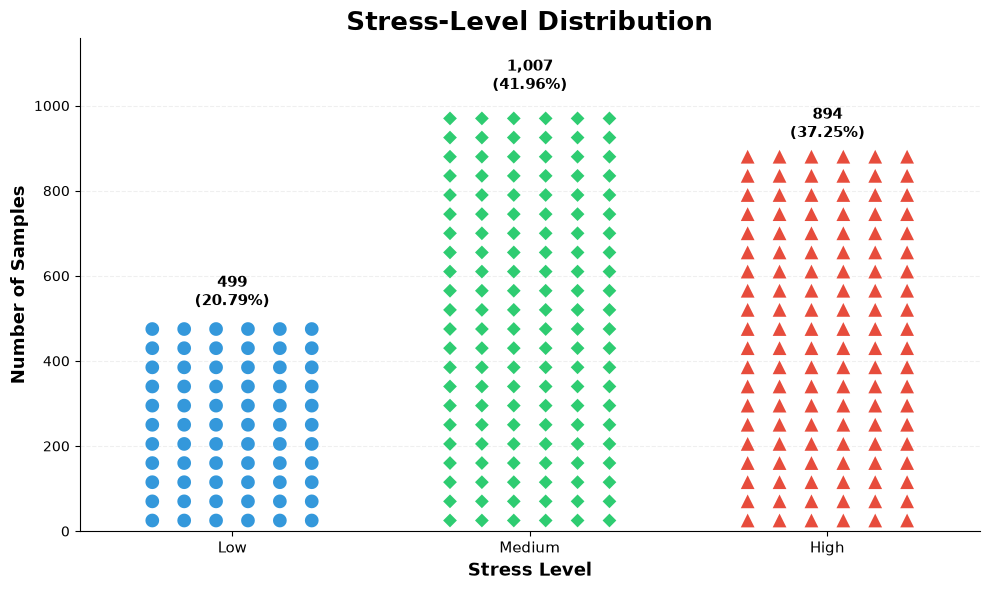

In [14]:
# Target distribution

target_counts = (
    df[TARGET]
    .value_counts()
    .reindex(STRESS_ORDER)
)

target_percent = (
    target_counts /
    len(df) *
    100
).round(2)

target_summary = pd.DataFrame({
    "Samples": target_counts,
    "Percentage": target_percent
})

majority_class = target_counts.idxmax()
minority_class = target_counts.idxmin()

imbalance_ratio = (
    target_counts.max() /
    target_counts.min()
)

print("Stress-Level Distribution:")
display(target_summary)

print(f"Majority class: {majority_class}")
print(f"Minority class: {minority_class}")
print(
    f"Majority/minority ratio: "
    f"{imbalance_ratio:.2f}:1"
)

# Custom sign styles
styles = {
    "Low": {
        "sign": "●",
        "color": "#3498DB"
    },
    "Medium": {
        "sign": "◆",
        "color": "#2ECC71"
    },
    "High": {
        "sign": "▲",
        "color": "#E74C3C"
    }
}

labels = list(
    target_summary.index
)

counts = (
    target_summary[
        "Samples"
    ].tolist()
)

percentages = (
    target_summary[
        "Percentage"
    ].tolist()
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

x_positions = np.arange(
    len(labels)
)

bar_width = 0.75

ax.bar(
    x_positions,
    counts,
    width=bar_width,
    color="white",
    edgecolor="none",
    linewidth=0,
    zorder=1
)

for i, label in enumerate(labels):

    count = counts[i]

    sign = styles[label]["sign"]
    color = styles[label]["color"]

    bar_left = (
        x_positions[i] -
        bar_width / 2
    )

    cols = 6

    x_spacing = (
        bar_width /
        (cols + 1)
    )

    y_spacing = 45

    for y in np.arange(
        25,
        count,
        y_spacing
    ):

        for col in range(cols):

            x = (
                bar_left +
                (col + 1) *
                x_spacing
            )

            txt = ax.text(
                x,
                y,
                sign,
                ha="center",
                va="center",
                fontsize=13,
                fontweight="bold",
                color=color,
                zorder=2
            )

            clip = Rectangle(
                (bar_left, 0),
                bar_width,
                count,
                transform=ax.transData
            )

            txt.set_clip_path(clip)

    ax.text(
        x_positions[i],
        count + 20,
        f"{count:,}\n({percentages[i]:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    labels,
    fontsize=11
)

ax.set_title(
    "Stress-Level Distribution",
    fontsize=19,
    fontweight="bold"
)

ax.set_xlabel(
    "Stress Level",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Samples",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylim(
    0,
    target_summary["Samples"].max() * 1.15
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "03_target_distribution_sign_filled.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

target_summary.to_csv(
    RESULTS_DIR /
    "03_target_distribution.csv"
)

## Numerical distributions

This answers:

Are variables skewed?
Are there multiple modes?
Are there suspicious tails?
Are variables approximately Gaussian?

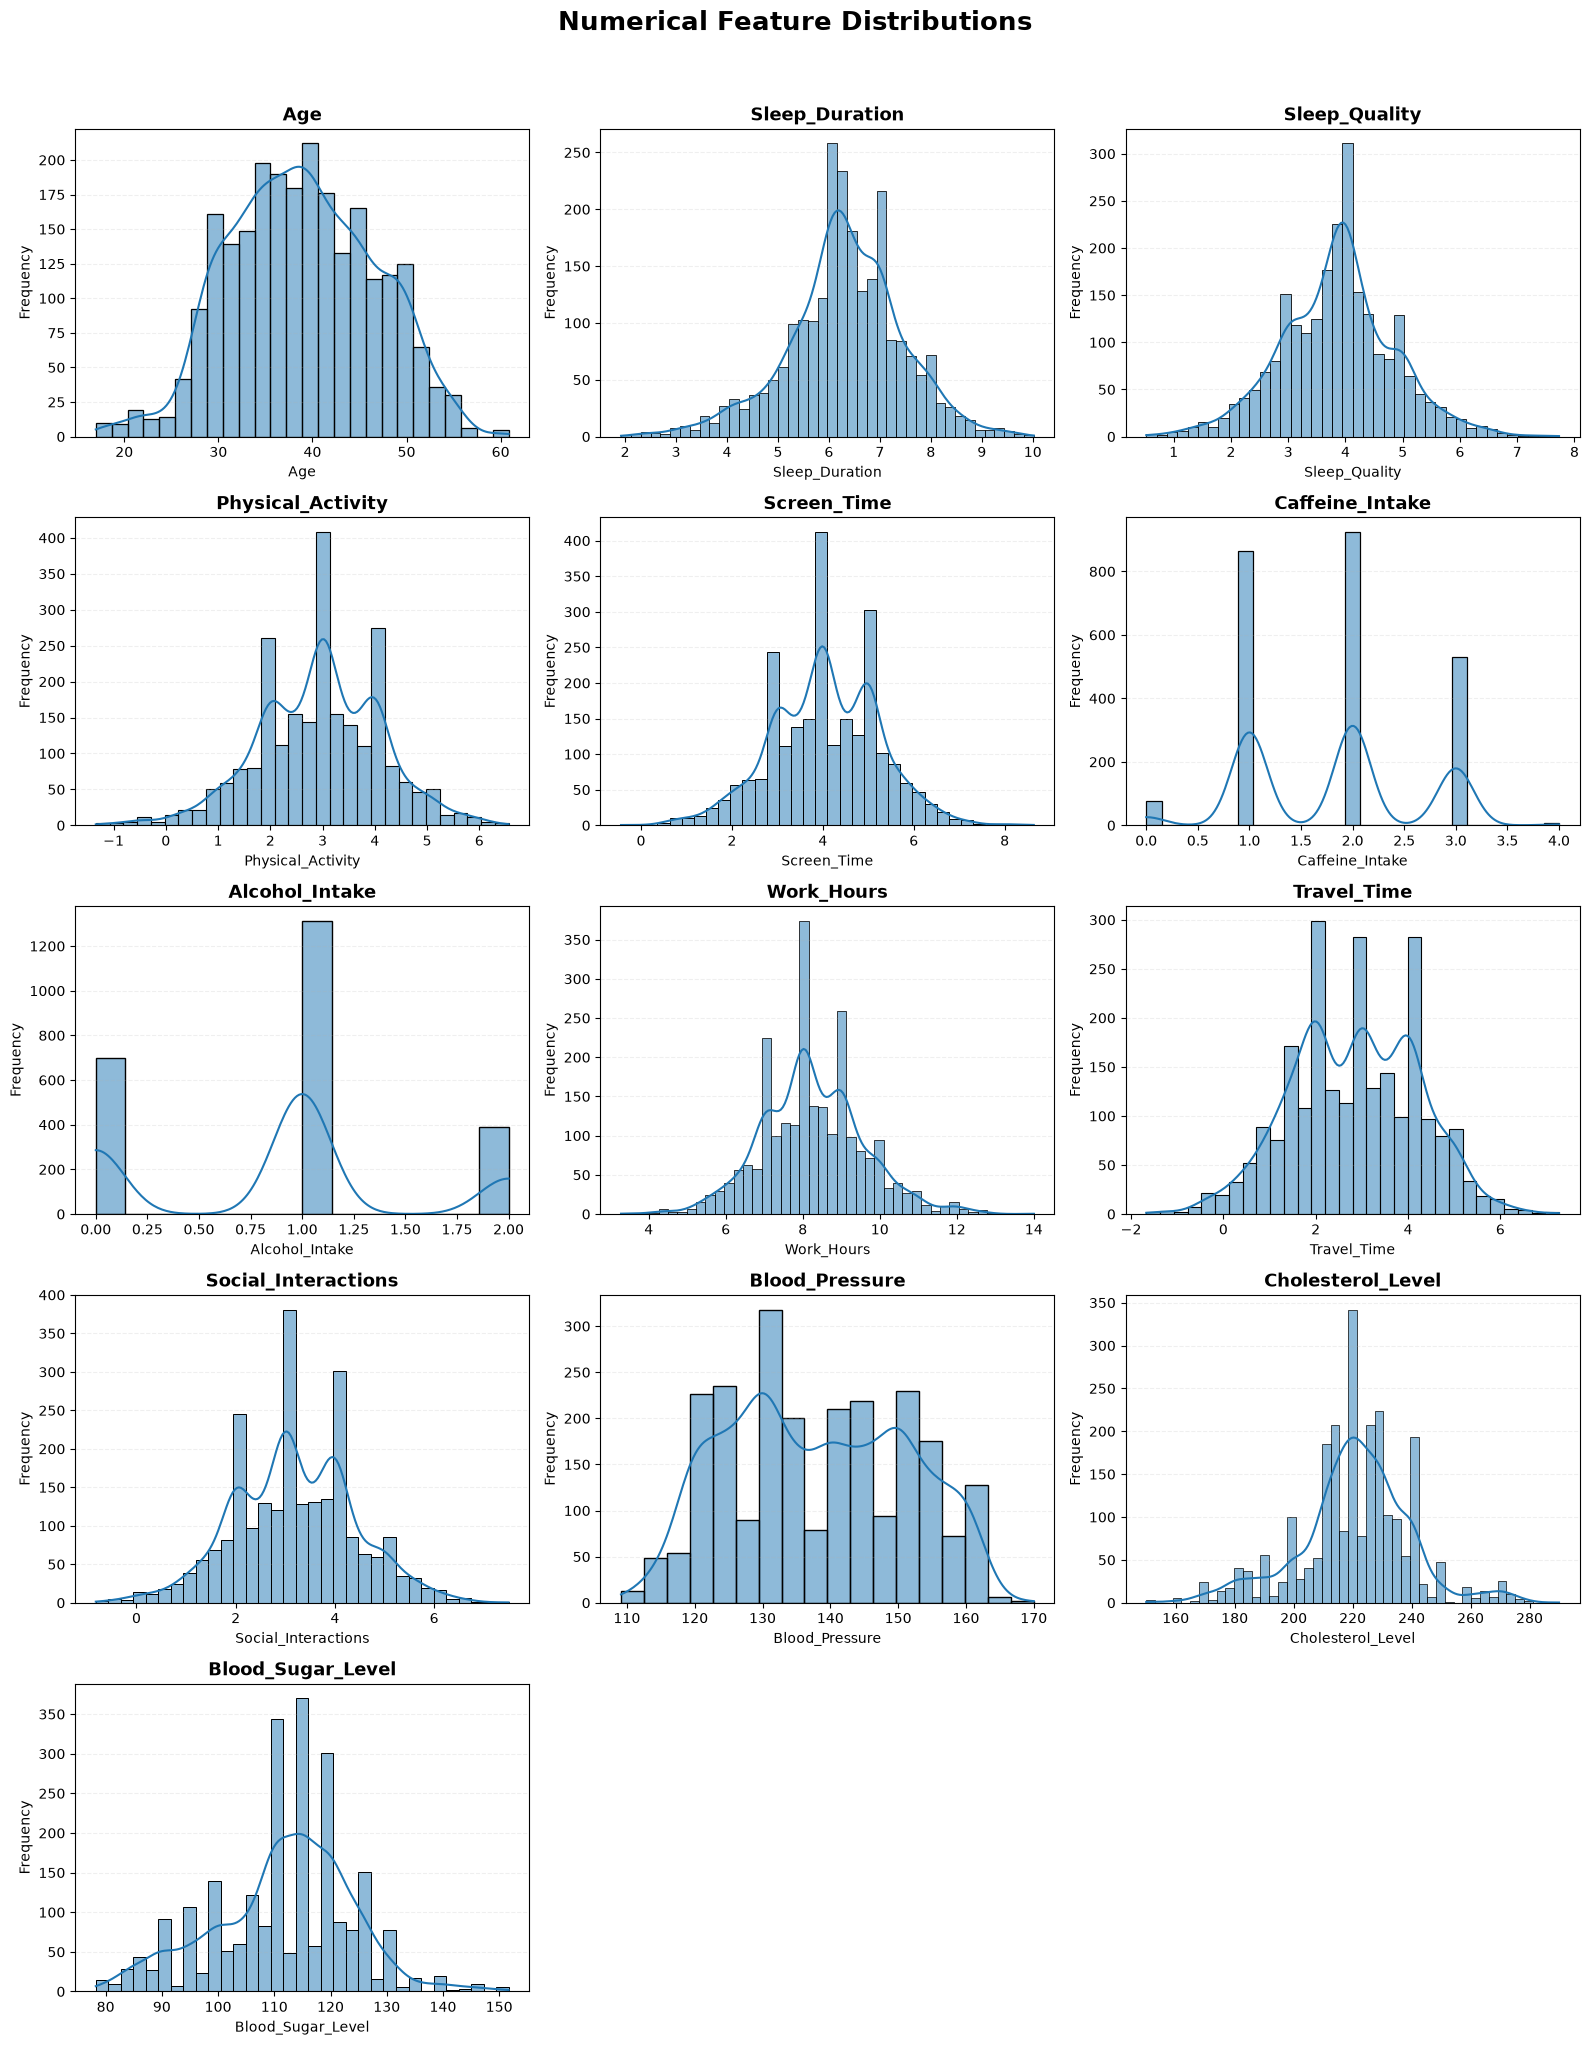

In [15]:
# Numerical distributions

n_features = len(numeric_features)

n_cols = 3
n_rows = int(
    np.ceil(
        n_features / n_cols
    )
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = np.array(
    axes
).reshape(-1)

for ax, feature in zip(
    axes,
    numeric_features
):

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=ax
    )

    ax.set_title(
        feature,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.2
    )

for ax in axes[
    n_features:
]:
    ax.axis("off")

fig.suptitle(
    "Numerical Feature Distributions",
    fontsize=19,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "04_numerical_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Numerical features across stress levels

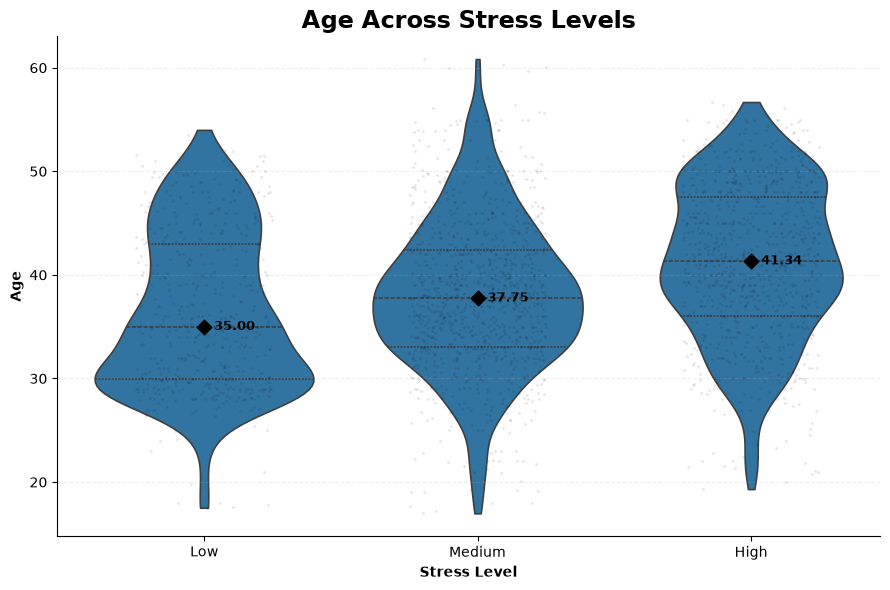

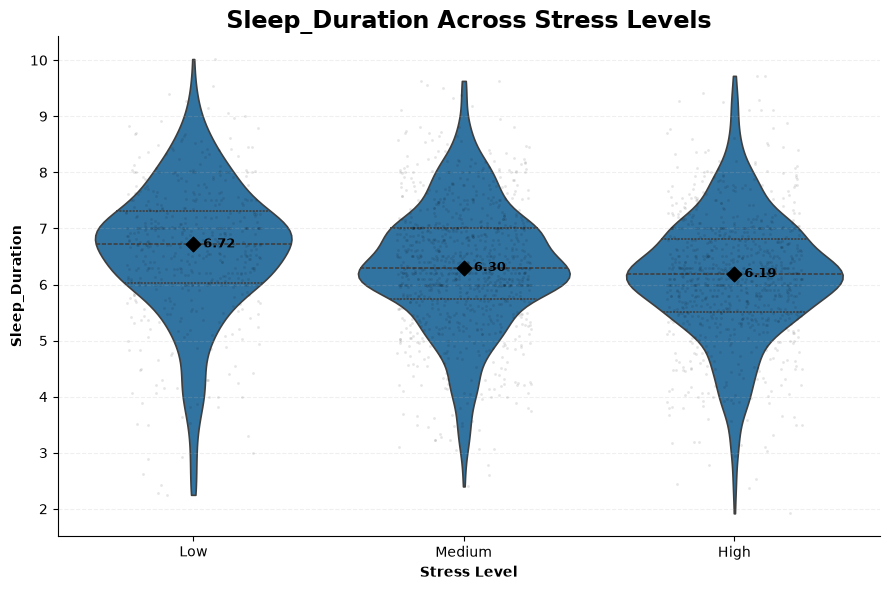

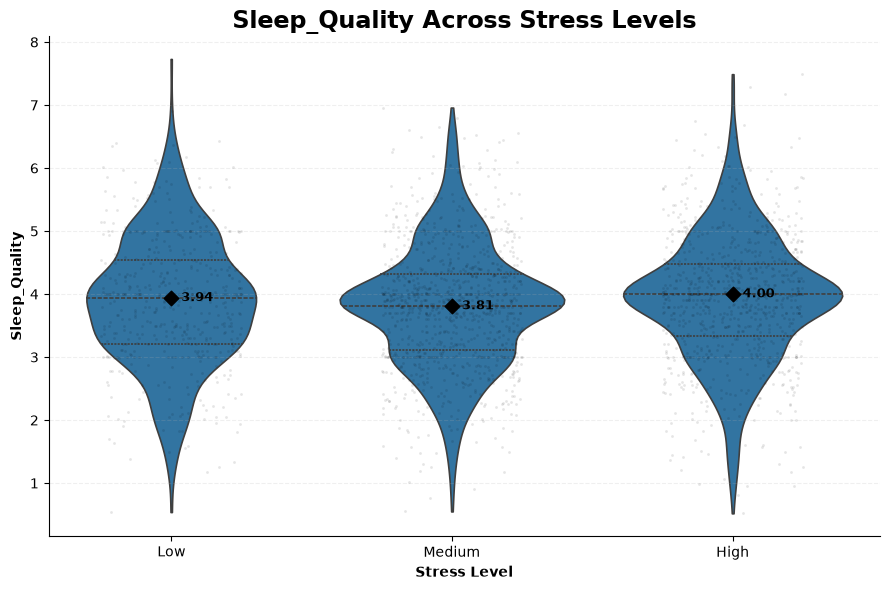

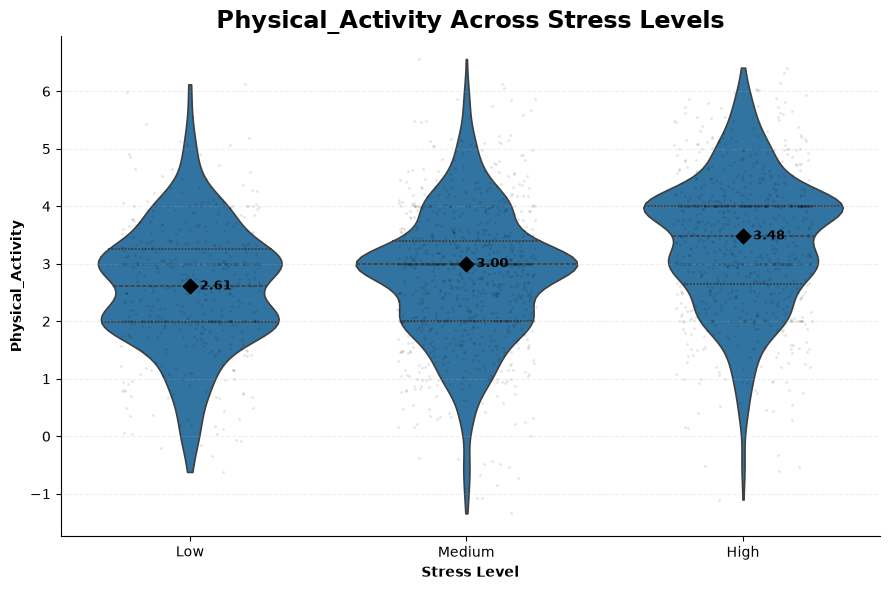

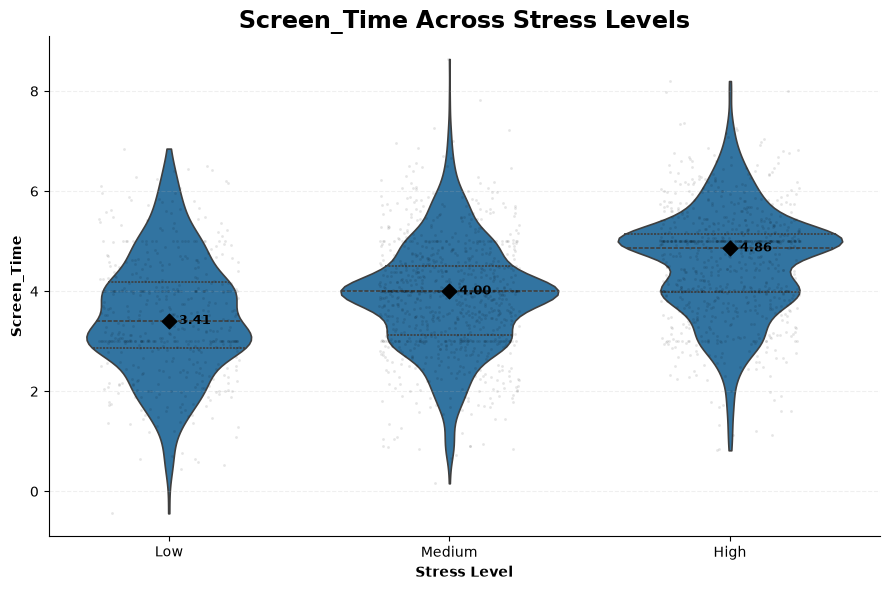

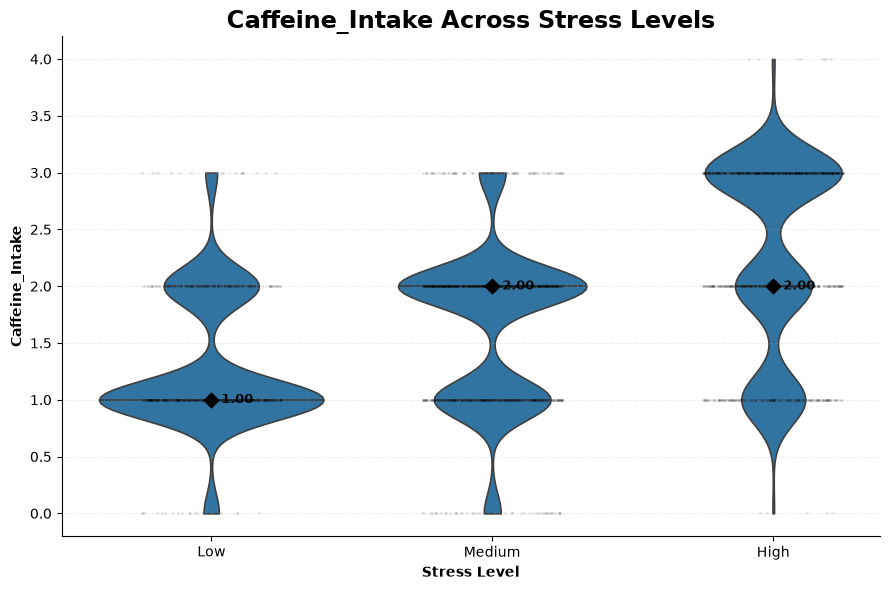

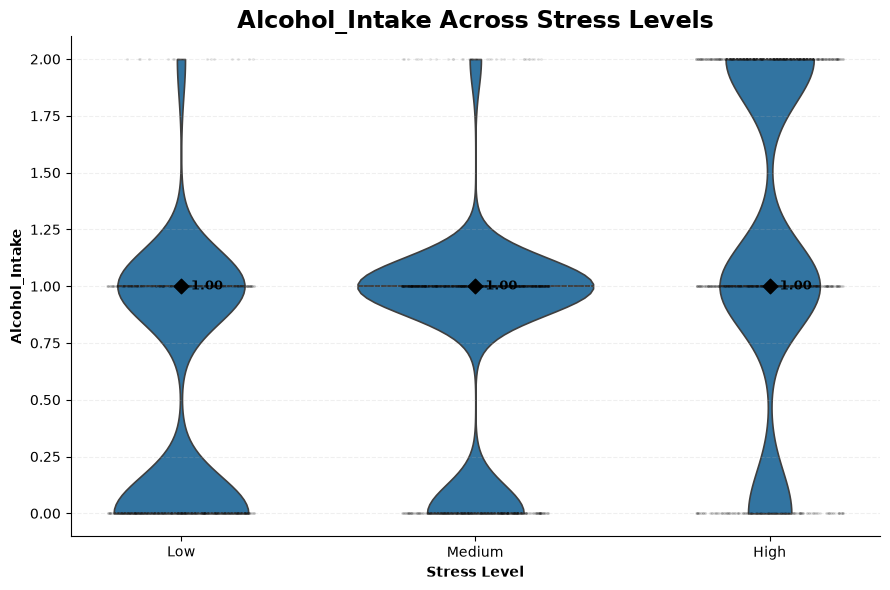

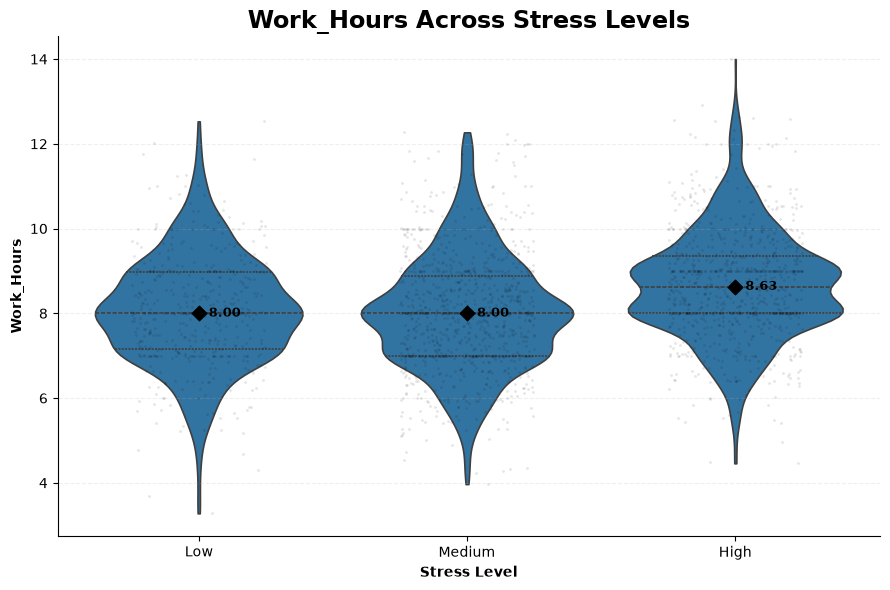

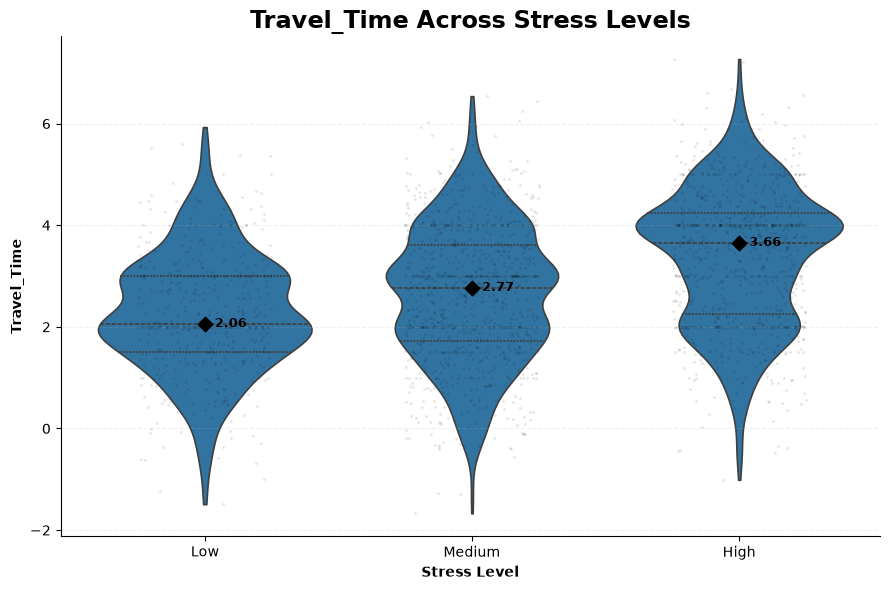

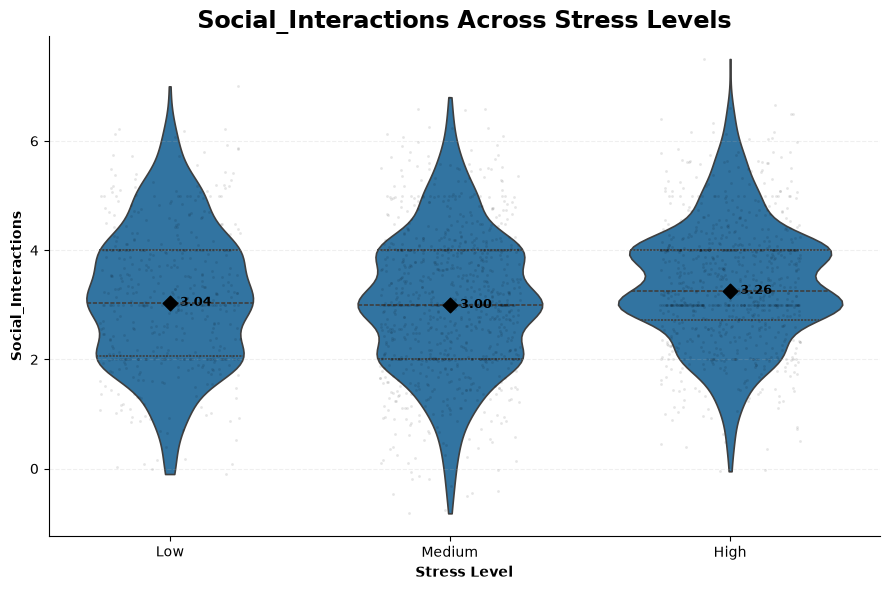

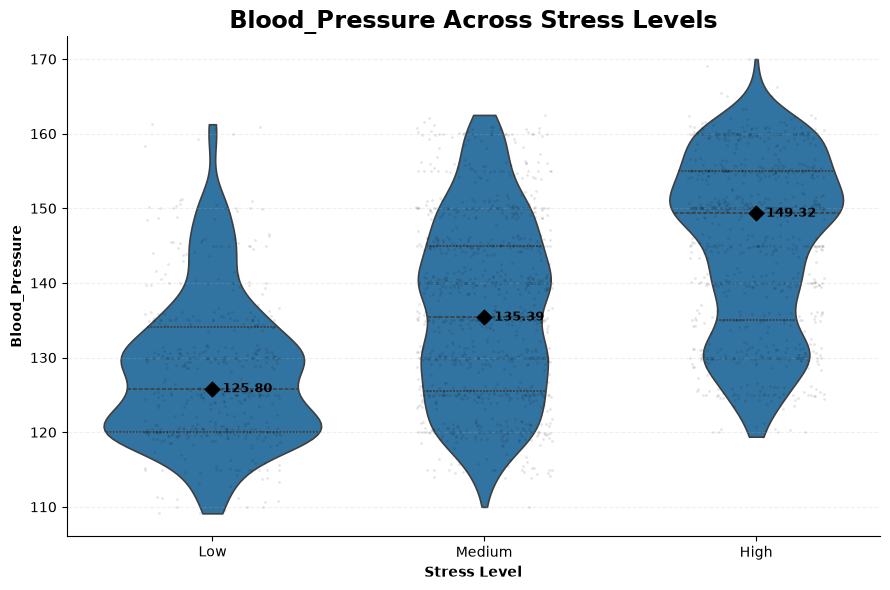

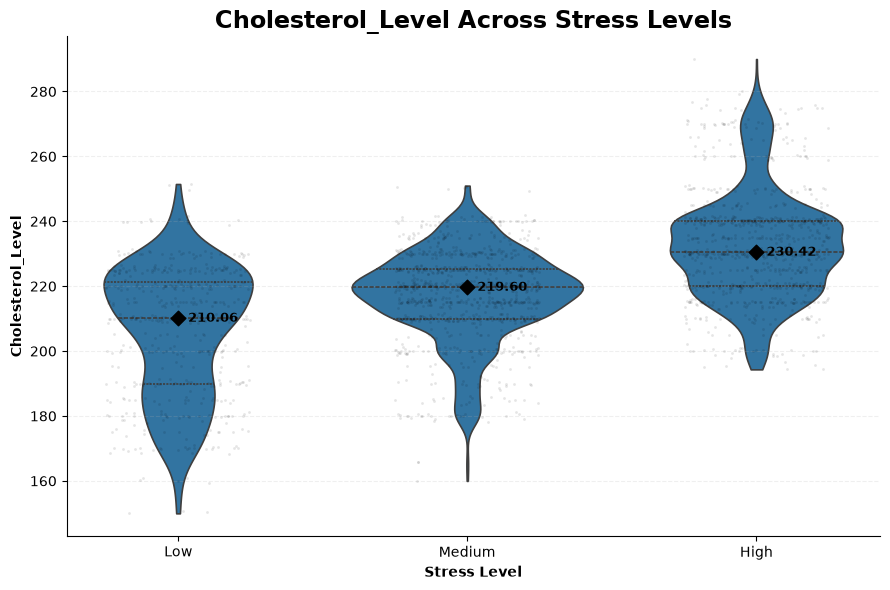

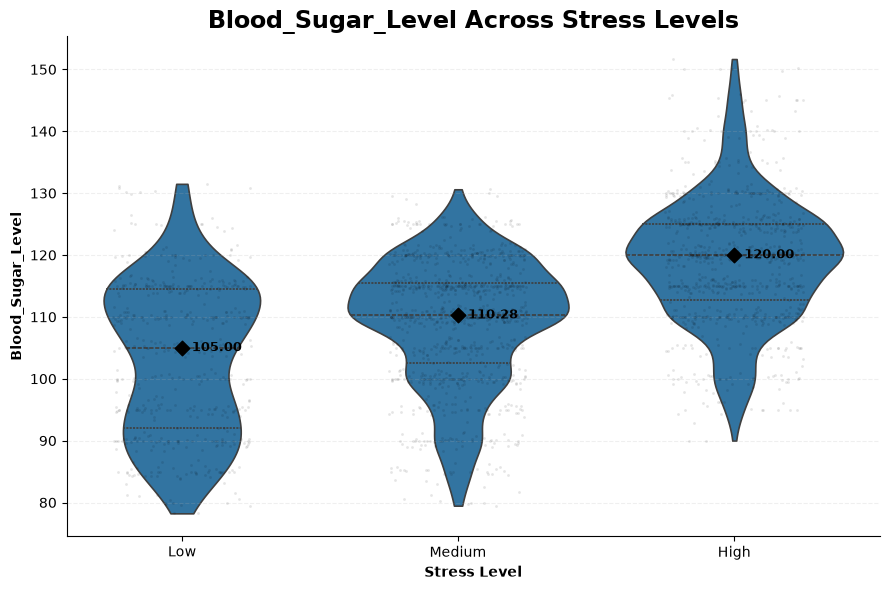

In [16]:
# Numerical distributions by stress level

for feature in numeric_features:

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    sns.violinplot(
        data=df,
        x=TARGET,
        y=feature,
        order=STRESS_ORDER,
        inner="quartile",
        cut=0,
        linewidth=1.2,
        ax=ax
    )

    sns.stripplot(
        data=df,
        x=TARGET,
        y=feature,
        order=STRESS_ORDER,
        color="black",
        alpha=0.10,
        size=2,
        jitter=0.25,
        ax=ax
    )

    medians = (
        df.groupby(
            TARGET,
            observed=False
        )[feature]
        .median()
        .reindex(
            STRESS_ORDER
        )
    )

    for i, value in enumerate(
        medians.values
    ):

        ax.scatter(
            i,
            value,
            marker="D",
            s=55,
            color="black",
            zorder=5
        )

        ax.text(
            i,
            value,
            f"  {value:.2f}",
            fontsize=9,
            fontweight="bold",
            va="center"
        )

    ax.set_title(
        f"{feature} Across Stress Levels",
        fontsize=17,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Stress Level",
        fontweight="bold"
    )

    ax.set_ylabel(
        feature,
        fontweight="bold"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.2
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    safe_name = (
        feature
        .replace(" ", "_")
        .replace("/", "_")
    )

    plt.savefig(
        RESULTS_DIR /
        f"05_violin_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Numerical stress profile

Instead of another plot only, this produces a thesis-useful table of mean, median, standard deviation and IQR.

In [17]:
# Numerical stress profile

profile_rows = []

for feature in numeric_features:

    for stress in STRESS_ORDER:

        values = df.loc[
            df[TARGET] == stress,
            feature
        ].dropna()

        profile_rows.append({
            "feature": feature,
            "stress_level": stress,
            "mean": values.mean(),
            "median": values.median(),
            "std": values.std(),
            "q1": values.quantile(0.25),
            "q3": values.quantile(0.75),
            "iqr": (
                values.quantile(0.75) -
                values.quantile(0.25)
            )
        })

numerical_stress_profile = pd.DataFrame(
    profile_rows
)

display(
    numerical_stress_profile
)

numerical_stress_profile.to_csv(
    RESULTS_DIR /
    "06_numerical_stress_profile.csv",
    index=False
)

,feature,stress_level,mean,median,std,q1,q3,iqr
0,Age,Low,36.367595,35.000,7.561507,29.9750,42.9700,12.9950
1,Age,Medium,38.031221,37.750,7.274837,33.0800,42.4250,9.3450
2,Age,High,41.263076,41.335,7.421777,36.0675,47.4950,11.4275
3,Sleep_Duration,Low,6.616132,6.720,1.191478,6.0350,7.3150,1.2800
4,Sleep_Duration,Medium,6.309494,6.300,1.113180,5.7350,7.0000,1.2650
5,Sleep_Duration,High,6.132081,6.190,1.100940,5.5125,6.8200,1.3075
6,Sleep_Quality,Low,3.885812,3.940,1.032470,3.2150,4.5400,1.3250
7,Sleep_Quality,Medium,3.792363,3.810,0.962714,3.1200,4.3150,1.1950
8,Sleep_Quality,High,3.917271,4.000,0.989753,3.3400,4.4775,1.1375
9,Physical_Activity,Low,2.562465,2.610,1.083386,1.9950,3.2500,1.2550


## Numerical feature vs stress association

Use Spearman, because stress level is ordinal and the relationships do not need to be linear.

In [18]:
# Numerical feature-stress association

association_rows = []

stress_codes = (
    df[TARGET]
    .cat.codes
)

for feature in numeric_features:

    valid = pd.DataFrame({
        "feature": df[feature],
        "stress": stress_codes
    }).dropna()

    rho, p_value = spearmanr(
        valid["feature"],
        valid["stress"]
    )

    association_rows.append({
        "feature": feature,
        "spearman_rho": rho,
        "absolute_rho": abs(rho),
        "p_value": p_value
    })

numerical_association = (
    pd.DataFrame(
        association_rows
    )
    .sort_values(
        "absolute_rho",
        ascending=False
    )
)

print(
    "Numerical Features Ranked by "
    "Absolute Spearman Association"
)

display(
    numerical_association
)

numerical_association.to_csv(
    RESULTS_DIR /
    "07_numerical_stress_association.csv",
    index=False
)

Numerical Features Ranked by Absolute Spearman Association


,feature,spearman_rho,absolute_rho,p_value
11,Cholesterol_Level,0.507489,0.507489,2.750391e-157
10,Blood_Pressure,0.493130,0.493130,2.708757e-147
12,Blood_Sugar_Level,0.489884,0.489884,4.226629e-145
5,Caffeine_Intake,0.451061,0.451061,1.280070e-120
6,Alcohol_Intake,0.382051,0.382051,2.947217e-84
4,Screen_Time,0.366683,0.366683,2.856914e-77
8,Travel_Time,0.324580,0.324580,5.371352e-60
3,Physical_Activity,0.291949,0.291949,2.266337e-48
0,Age,0.259670,0.259670,2.779605e-38
7,Work_Hours,0.207210,0.207210,1.095863e-24


## Spearman correlation heatmap

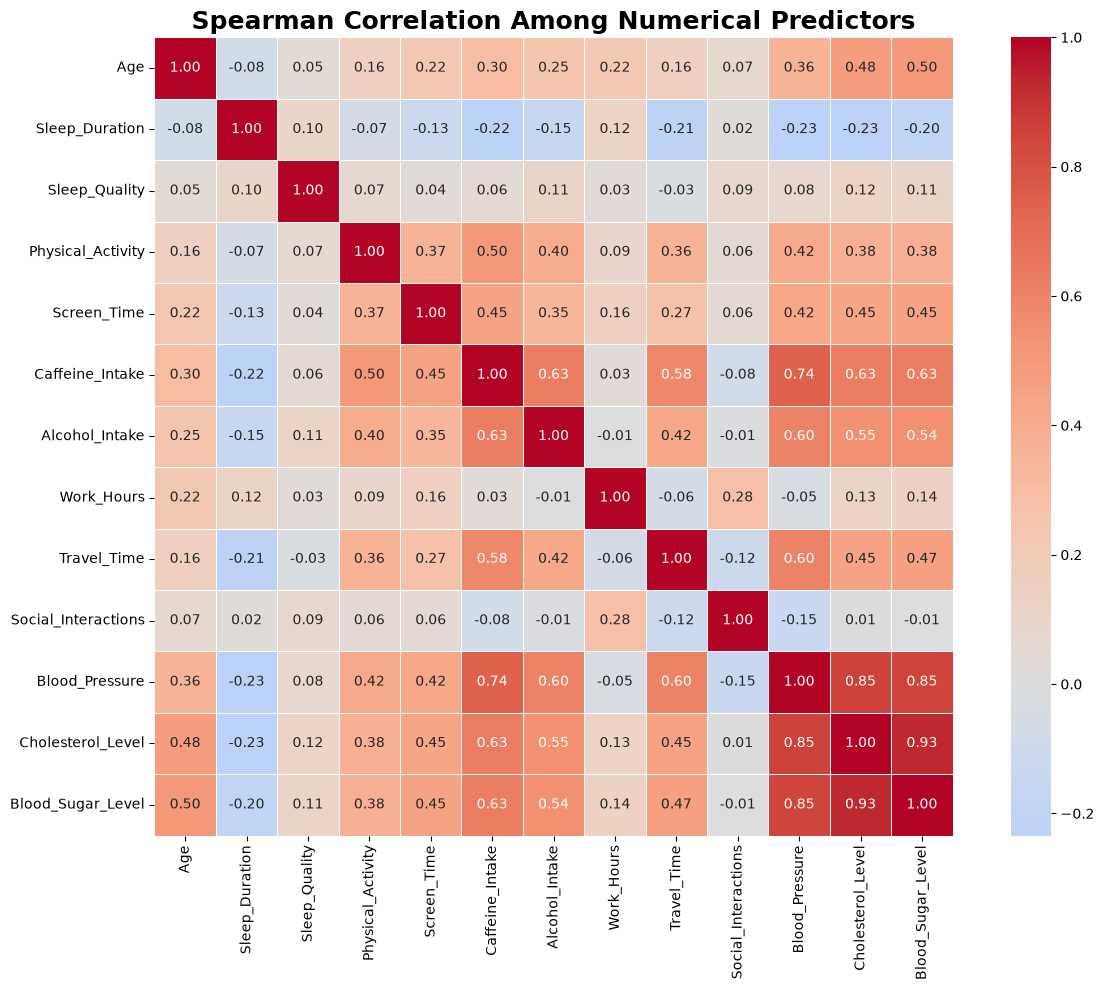

Highly correlated numerical pairs


,feature_1,feature_2,spearman_rho,absolute_rho
3,Cholesterol_Level,Blood_Sugar_Level,0.934346,0.934346
1,Blood_Pressure,Cholesterol_Level,0.852623,0.852623
2,Blood_Pressure,Blood_Sugar_Level,0.845501,0.845501
0,Caffeine_Intake,Blood_Pressure,0.741366,0.741366


In [19]:
# Spearman correlation matrix

corr = (
    df[numeric_features]
    .corr(
        method="spearman"
    )
)

fig, ax = plt.subplots(
    figsize=(13, 10)
)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    "Spearman Correlation Among Numerical Predictors",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "08_spearman_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# High-correlation pairs

HIGH_CORR_THRESHOLD = 0.70

corr_pairs = []

for i in range(
    len(corr.columns)
):

    for j in range(
        i + 1,
        len(corr.columns)
    ):

        value = corr.iloc[i, j]

        if abs(value) >= HIGH_CORR_THRESHOLD:

            corr_pairs.append({
                "feature_1":
                    corr.columns[i],
                "feature_2":
                    corr.columns[j],
                "spearman_rho":
                    value,
                "absolute_rho":
                    abs(value)
            })

high_corr_pairs = (
    pd.DataFrame(
        corr_pairs
    )
    .sort_values(
        "absolute_rho",
        ascending=False
    )
)

print(
    "Highly correlated numerical pairs"
)

if len(high_corr_pairs) > 0:
    display(high_corr_pairs)
else:
    print(
        "No predictor pair exceeded "
        f"|rho| >= {HIGH_CORR_THRESHOLD}."
    )

high_corr_pairs.to_csv(
    RESULTS_DIR /
    "08_high_correlation_pairs.csv",
    index=False
)

## Relationships of strongest features

This is much more useful for your thesis than a random scatterplot matrix because it focuses on variables that actually show relationship with stress.

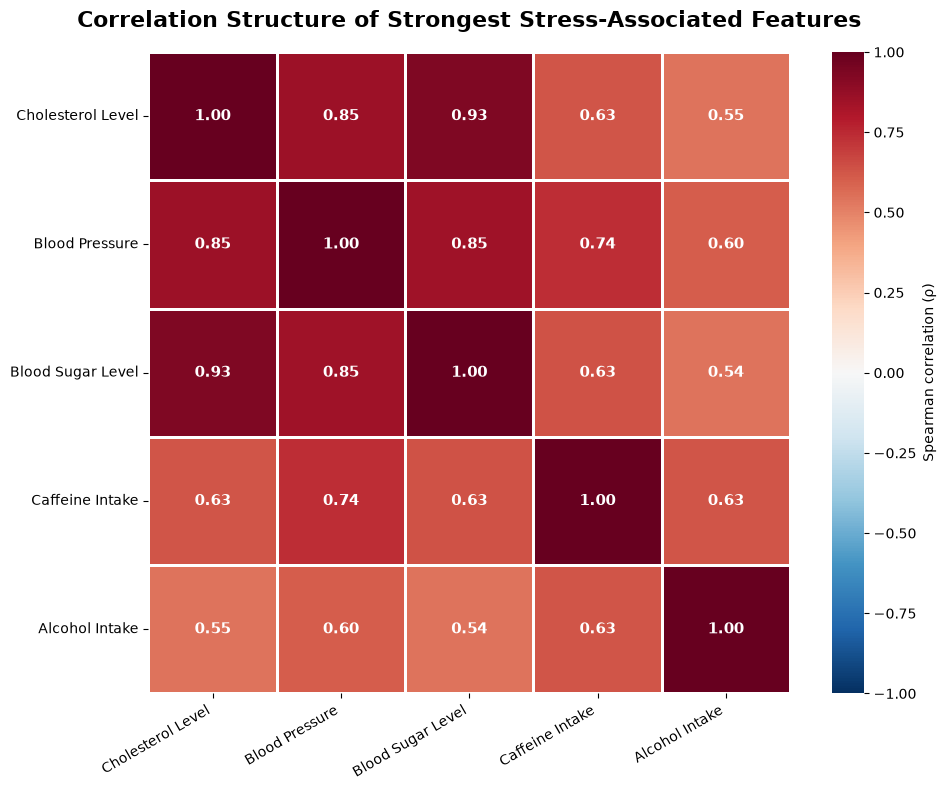

Strongest numerical features:
1. Cholesterol_Level
2. Blood_Pressure
3. Blood_Sugar_Level
4. Caffeine_Intake
5. Alcohol_Intake

Strongest pairwise correlations:


,Feature_1,Feature_2,Spearman_Rho
2,Cholesterol_Level,Blood_Sugar_Level,0.934
1,Cholesterol_Level,Blood_Pressure,0.853
7,Blood_Pressure,Blood_Sugar_Level,0.846
8,Blood_Pressure,Caffeine_Intake,0.741
13,Blood_Sugar_Level,Caffeine_Intake,0.633
19,Caffeine_Intake,Alcohol_Intake,0.631
3,Cholesterol_Level,Caffeine_Intake,0.627
9,Blood_Pressure,Alcohol_Intake,0.602
4,Cholesterol_Level,Alcohol_Intake,0.545
14,Blood_Sugar_Level,Alcohol_Intake,0.543


In [31]:

TOP_NUMERIC = min(
    5,
    len(numerical_association)
)

top_numeric_features = (
    numerical_association
    .head(TOP_NUMERIC)["feature"]
    .tolist()
)

correlation_matrix = df[
    top_numeric_features
].corr(method="spearman")

# Rename labels for readability
display_labels = {
    feature: feature.replace("_", " ")
    for feature in top_numeric_features
}

plot_matrix = correlation_matrix.rename(
    index=display_labels,
    columns=display_labels
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

sns.heatmap(
    plot_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
    linecolor="white",
    cbar_kws={
        "label": "Spearman correlation (ρ)"
    },
    annot_kws={
        "fontsize": 11,
        "fontweight": "bold"
    },
    ax=ax
)

ax.set_title(
    "Correlation Structure of Strongest Stress-Associated Features",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("")
ax.set_ylabel("")

plt.xticks(
    rotation=30,
    ha="right",
    fontsize=10
)

plt.yticks(
    rotation=0,
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "09_strong_feature_correlation_structure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Strongest numerical features:")
for i, feature in enumerate(top_numeric_features, start=1):
    print(f"{i}. {feature}")

print("\nStrongest pairwise correlations:")

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

strong_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

strong_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Spearman_Rho"
]

strong_pairs["Absolute_Rho"] = (
    strong_pairs["Spearman_Rho"].abs()
)

strong_pairs = strong_pairs.sort_values(
    "Absolute_Rho",
    ascending=False
)

display(
    strong_pairs[
        [
            "Feature_1",
            "Feature_2",
            "Spearman_Rho"
        ]
    ].round(3)
)

## PCA structure

PCA is useful here because later you're building a graph representation. We want to know whether the numerical variables contain a compact latent structure.

Number of numerical features: 13
Number of principal components: 13


,Component,Explained_Variance_%,Cumulative_Variance_%
0,1,37.80,37.80
1,2,11.55,49.35
2,3,8.44,57.79
3,4,7.65,65.44
4,5,7.19,72.62
5,6,5.54,78.17
6,7,4.98,83.14
7,8,4.87,88.01
8,9,4.32,92.33
9,10,3.99,96.32


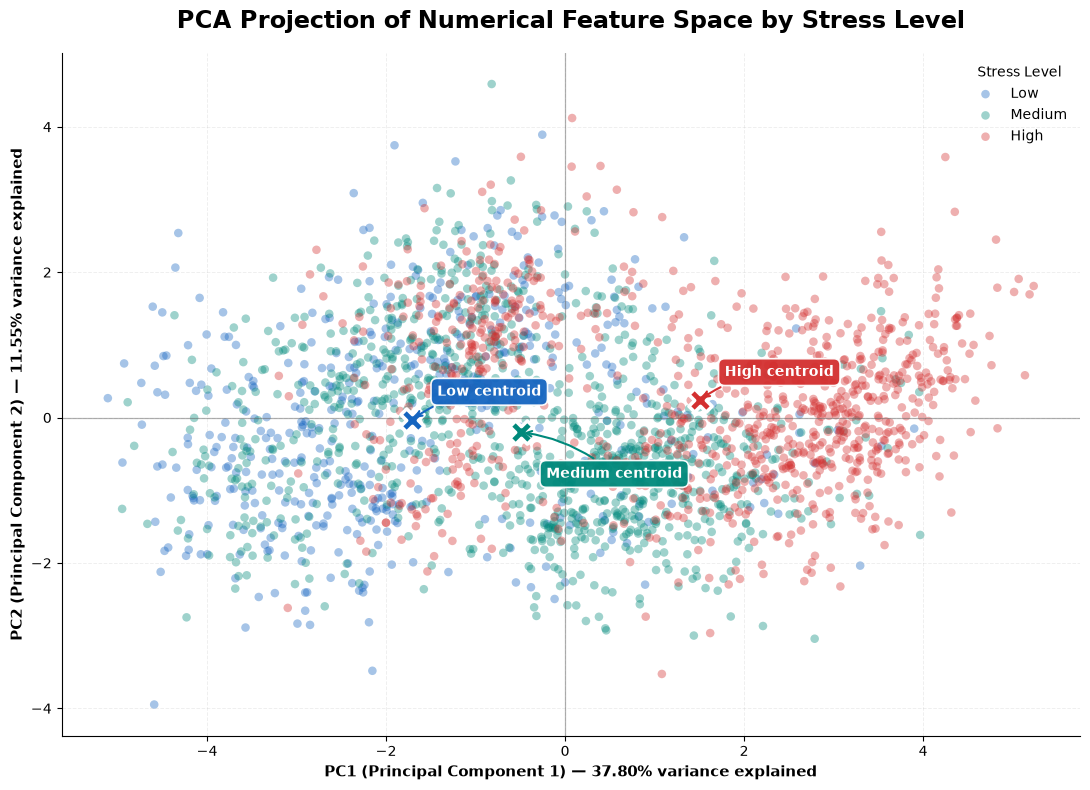

Stress-level centroids in PCA space:


,PC1,PC2
Stress_Detection,,
Low,-1.707,-0.027
Medium,-0.490,-0.202
High,1.505,0.243


PC1 explains 37.80% of total variance.
PC2 explains 11.55% of total variance.
PC1 + PC2 explain 49.35% of total variance.
PC1–PC10 explain 96.32% of total variance.


In [35]:

# Prepare numerical data
X_numeric = df[numeric_features].copy()

# Exploratory median imputation only
X_numeric = X_numeric.fillna(
    X_numeric.median()
)

# Standardize numerical predictors
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_numeric
)

# Fit PCA
pca = PCA(
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(
    X_scaled
)

# Explained variance
explained_variance = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(
    explained_variance
)

# PCA summary
pca_summary = pd.DataFrame({
    "Component": np.arange(
        1,
        len(explained_variance) + 1
    ),
    "Explained_Variance_%":
        explained_variance * 100,
    "Cumulative_Variance_%":
        cumulative_variance * 100
})

print(
    f"Number of numerical features: {len(numeric_features)}"
)

print(
    f"Number of principal components: {len(explained_variance)}"
)

display(
    pca_summary.round(2)
)

# Create 2D PCA projection
pca_2d = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    TARGET: df[TARGET].astype(str)
})

# Calculate stress-level centroids
centroids = (
    pca_2d
    .groupby(TARGET)[["PC1", "PC2"]]
    .mean()
    .reindex(STRESS_ORDER)
)

# Dark bright colors
stress_colors = {
    "Low": "#1565C0",
    "Medium": "#00897B",
    "High": "#D32F2F"
}

# Create figure
fig, ax = plt.subplots(
    figsize=(11, 8)
)

# Plot observations
for stress in STRESS_ORDER:

    subset = pca_2d[
        pca_2d[TARGET] == stress
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=38,
        alpha=0.38,
        color=stress_colors[stress],
        label=stress,
        edgecolors="none"
    )

# Different label positions prevent overlap
label_offsets = {
    "Low": (18, 20),
    "Medium": (18, -30),
    "High": (18, 20)
}

# Plot centroids and visible labels
for stress in STRESS_ORDER:

    centroid = centroids.loc[stress]

    # Centroid marker
    ax.scatter(
        centroid["PC1"],
        centroid["PC2"],
        s=280,
        marker="X",
        color=stress_colors[stress],
        edgecolor="white",
        linewidth=2.5,
        zorder=6
    )

    # Centroid label
    ax.annotate(
        f"{stress} centroid",
        xy=(
            centroid["PC1"],
            centroid["PC2"]
        ),
        xytext=label_offsets[stress],
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color="white",
        ha="left",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor=stress_colors[stress],
            edgecolor="white",
            linewidth=1.2,
            alpha=0.95
        ),
        arrowprops=dict(
            arrowstyle="->",
            color=stress_colors[stress],
            linewidth=1.5,
            connectionstyle="arc3,rad=0.15"
        ),
        zorder=10
    )

# Reference axes
ax.axhline(
    0,
    color="#555555",
    linewidth=0.9,
    alpha=0.45
)

ax.axvline(
    0,
    color="#555555",
    linewidth=0.9,
    alpha=0.45
)

# Title
ax.set_title(
    "PCA Projection of Numerical Feature Space by Stress Level",
    fontsize=17,
    fontweight="bold",
    pad=18
)

# Explicit PC labels
ax.set_xlabel(
    f"PC1 (Principal Component 1) — "
    f"{explained_variance[0] * 100:.2f}% variance explained",
    fontsize=11,
    fontweight="bold"
)

ax.set_ylabel(
    f"PC2 (Principal Component 2) — "
    f"{explained_variance[1] * 100:.2f}% variance explained",
    fontsize=11,
    fontweight="bold"
)

# Legend
ax.legend(
    title="Stress Level",
    title_fontsize=10,
    fontsize=10,
    frameon=False,
    loc="best"
)

# Grid
ax.grid(
    linestyle="--",
    linewidth=0.7,
    alpha=0.20
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save figure
plt.savefig(
    RESULTS_DIR /
    "10_pca_stress_projection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Display centroid coordinates
print("Stress-level centroids in PCA space:")

display(
    centroids.round(3)
)

# Key PCA findings
print(
    f"PC1 explains "
    f"{explained_variance[0] * 100:.2f}% "
    f"of total variance."
)

print(
    f"PC2 explains "
    f"{explained_variance[1] * 100:.2f}% "
    f"of total variance."
)

print(
    f"PC1 + PC2 explain "
    f"{cumulative_variance[1] * 100:.2f}% "
    f"of total variance."
)

print(
    f"PC1–PC10 explain "
    f"{cumulative_variance[9] * 100:.2f}% "
    f"of total variance."
)

## PCA explained variance

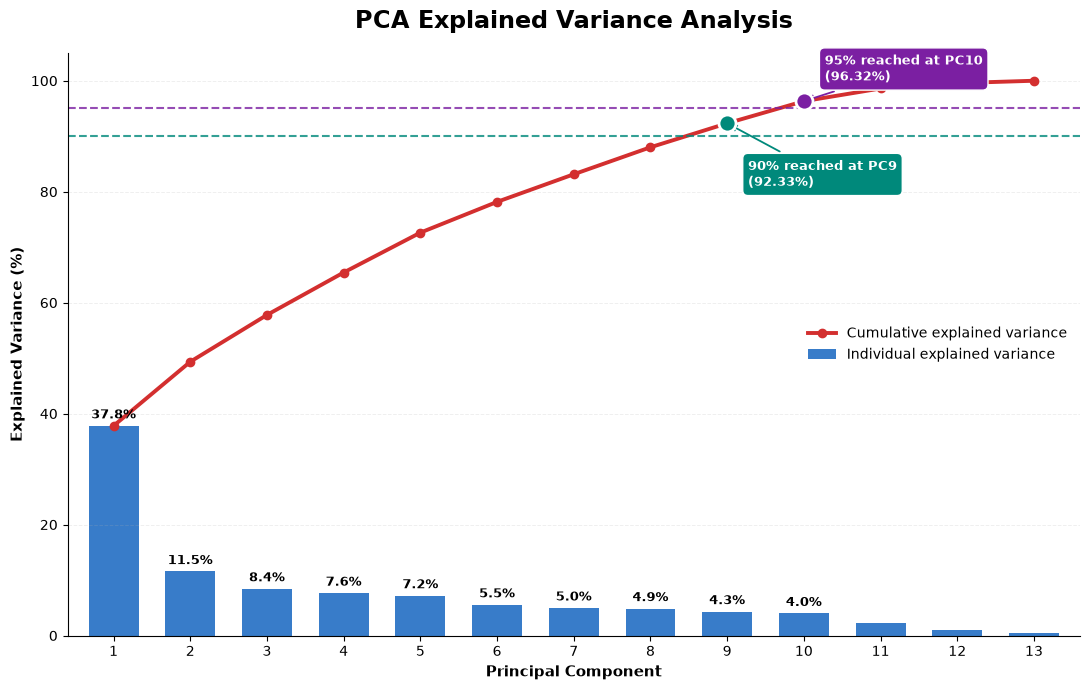

PC1 explains 37.80% of variance.
PC1 + PC2 explain 49.35% of variance.
PC1–PC5 explain 72.62% of variance.
90% variance is reached at PC9 (92.33%).
95% variance is reached at PC10 (96.32%).
PC1–PC10 explain 96.32% of variance.


In [37]:

# Prepare PCA variance values
components = np.arange(
    1,
    len(explained_variance) + 1
)

individual_percent = (
    explained_variance * 100
)

cumulative_percent = (
    cumulative_variance * 100
)

# Find variance thresholds
pc_90 = np.argmax(
    cumulative_variance >= 0.90
) + 1

pc_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

# Create figure
fig, ax = plt.subplots(
    figsize=(11, 7)
)

# Individual explained variance
ax.bar(
    components,
    individual_percent,
    width=0.65,
    color="#1565C0",
    alpha=0.85,
    label="Individual explained variance"
)

# Add percentage labels only for important components
for i, value in enumerate(individual_percent):

    if value >= 3:

        ax.text(
            components[i],
            value + 0.8,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

# Cumulative variance line
ax.plot(
    components,
    cumulative_percent,
    color="#D32F2F",
    marker="o",
    markersize=6,
    linewidth=2.8,
    label="Cumulative explained variance"
)

# 90% threshold
ax.axhline(
    90,
    color="#00897B",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# 95% threshold
ax.axhline(
    95,
    color="#7B1FA2",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# Mark 90% component
ax.scatter(
    pc_90,
    cumulative_percent[pc_90 - 1],
    s=150,
    color="#00897B",
    edgecolor="white",
    linewidth=2,
    zorder=5
)

ax.annotate(
    f"90% reached at PC{pc_90}\n"
    f"({cumulative_percent[pc_90 - 1]:.2f}%)",
    xy=(
        pc_90,
        cumulative_percent[pc_90 - 1]
    ),
    xytext=(15, -45),
    textcoords="offset points",
    fontsize=9.5,
    fontweight="bold",
    color="white",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#00897B",
        edgecolor="white",
        linewidth=1
    ),
    arrowprops=dict(
        arrowstyle="->",
        color="#00897B",
        linewidth=1.3
    )
)

# Mark 95% component
ax.scatter(
    pc_95,
    cumulative_percent[pc_95 - 1],
    s=150,
    color="#7B1FA2",
    edgecolor="white",
    linewidth=2,
    zorder=5
)

ax.annotate(
    f"95% reached at PC{pc_95}\n"
    f"({cumulative_percent[pc_95 - 1]:.2f}%)",
    xy=(
        pc_95,
        cumulative_percent[pc_95 - 1]
    ),
    xytext=(15, 15),
    textcoords="offset points",
    fontsize=9.5,
    fontweight="bold",
    color="white",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#7B1FA2",
        edgecolor="white",
        linewidth=1
    ),
    arrowprops=dict(
        arrowstyle="->",
        color="#7B1FA2",
        linewidth=1.3
    )
)

# Title
ax.set_title(
    "PCA Explained Variance Analysis",
    fontsize=17,
    fontweight="bold",
    pad=18
)

# Axis labels
ax.set_xlabel(
    "Principal Component",
    fontsize=11,
    fontweight="bold"
)

ax.set_ylabel(
    "Explained Variance (%)",
    fontsize=11,
    fontweight="bold"
)

# Axis settings
ax.set_xticks(
    components
)

ax.set_xlim(
    0.4,
    len(components) + 0.6
)

ax.set_ylim(
    0,
    105
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.20
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(
    frameon=False,
    fontsize=10,
    loc="center right"
)

plt.tight_layout()

# Save figure
plt.savefig(
    RESULTS_DIR /
    "11_pca_explained_variance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Save PCA summary
pca_summary.to_csv(
    RESULTS_DIR /
    "11_pca_explained_variance.csv",
    index=False
)

# Print important findings
print(
    f"PC1 explains "
    f"{individual_percent[0]:.2f}% of variance."
)

print(
    f"PC1 + PC2 explain "
    f"{cumulative_percent[1]:.2f}% of variance."
)

print(
    f"PC1–PC5 explain "
    f"{cumulative_percent[4]:.2f}% of variance."
)

print(
    f"90% variance is reached at "
    f"PC{pc_90} "
    f"({cumulative_percent[pc_90 - 1]:.2f}%)."
)

print(
    f"95% variance is reached at "
    f"PC{pc_95} "
    f"({cumulative_percent[pc_95 - 1]:.2f}%)."
)

print(
    f"PC1–PC10 explain "
    f"{cumulative_percent[9]:.2f}% of variance."
)

## Categorical cardinality

This is particularly important because it has a potentially very high-cardinality Occupation feature.

In [23]:
# Categorical feature cardinality

categorical_cardinality = pd.DataFrame({
    "feature": categorical_features,
    "unique_categories": [
        df[c].nunique(
            dropna=True
        )
        for c in categorical_features
    ],
    "missing": [
        df[c].isna().sum()
        for c in categorical_features
    ],
    "most_common_count": [
        df[c].value_counts(
            dropna=False
        ).iloc[0]
        for c in categorical_features
    ]
})

categorical_cardinality[
    "most_common_percent"
] = (
    categorical_cardinality[
        "most_common_count"
    ] /
    len(df) *
    100
)

categorical_cardinality = (
    categorical_cardinality
    .sort_values(
        "unique_categories",
        ascending=False
    )
)

display(
    categorical_cardinality
)

categorical_cardinality.to_csv(
    RESULTS_DIR /
    "12_categorical_cardinality.csv",
    index=False
)

,feature,unique_categories,missing,most_common_count,most_common_percent
1,Occupation,165,0,114,4.750000
4,Bed_Time,19,0,454,18.916667
3,Wake_Up_Time,10,0,550,22.916667
7,Exercise_Type,7,0,785,32.708333
2,Marital_Status,3,0,1095,45.625000
0,Gender,2,0,1215,50.625000
5,Smoking_Habit,2,0,1277,53.208333
6,Meditation_Practice,2,0,1468,61.166667


## Categorical stress composition: custom sign-filled

Instead of ordinary bars, each category shows its Low / Medium / High composition.

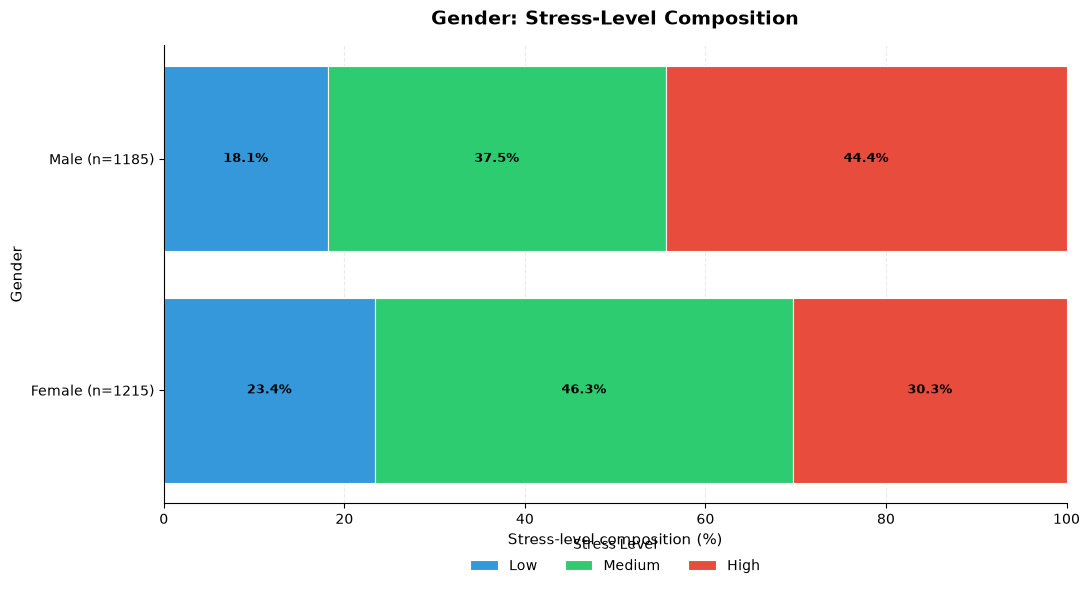

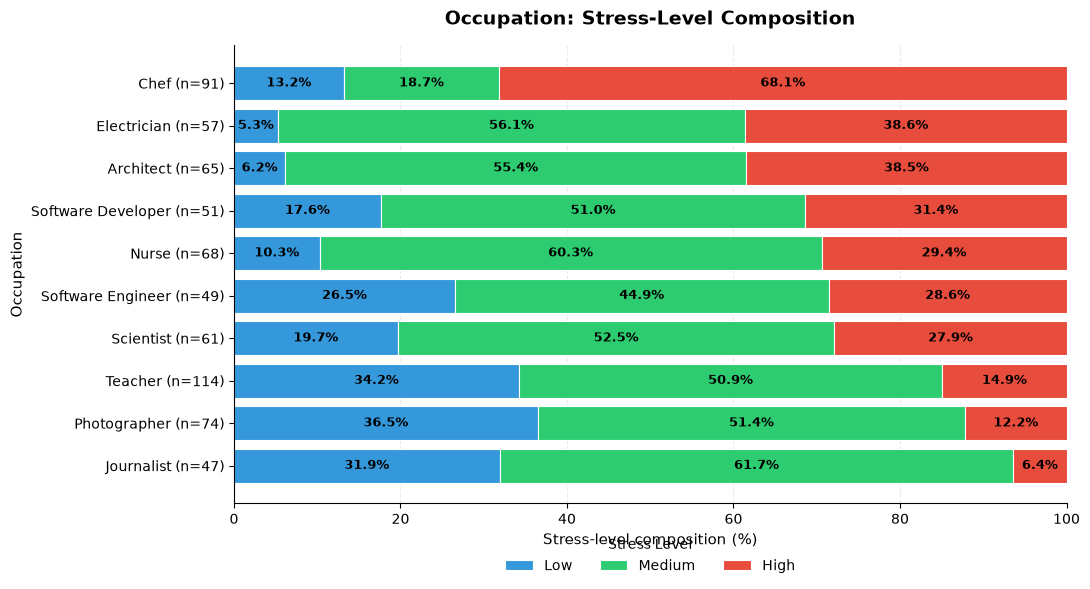

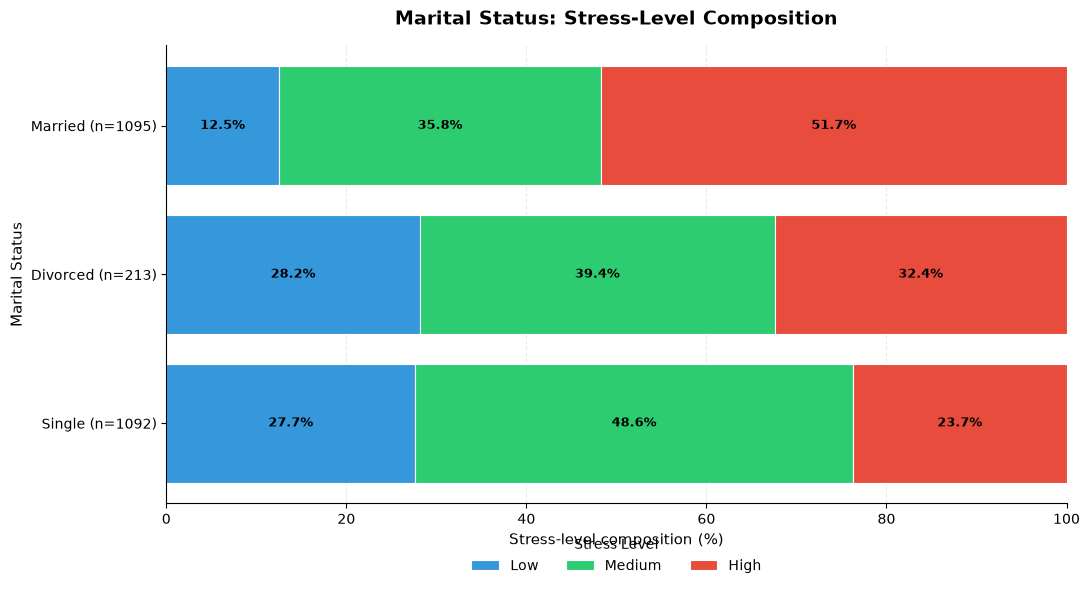

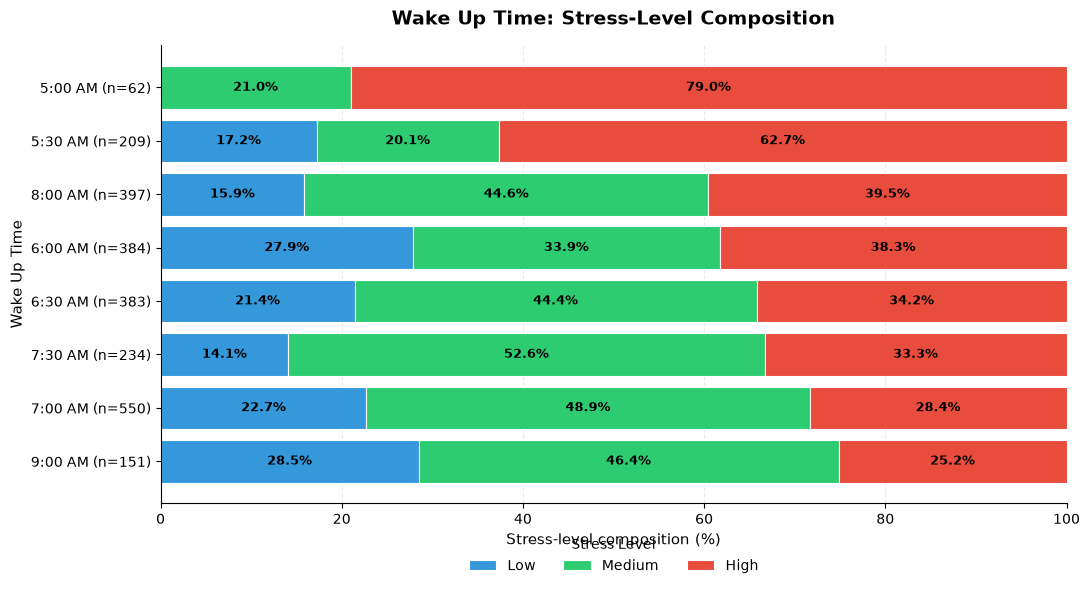

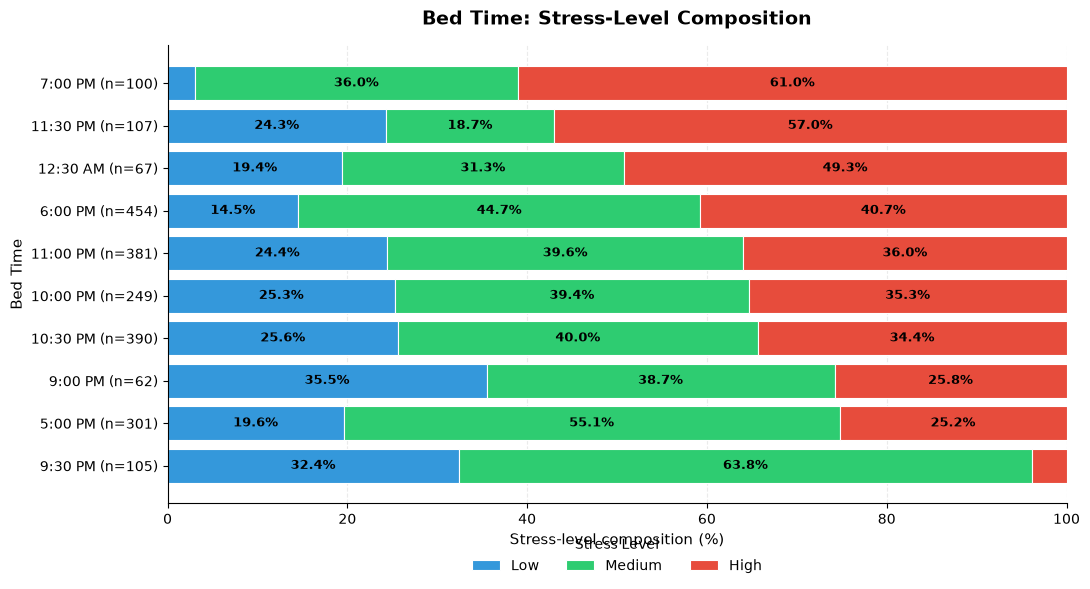

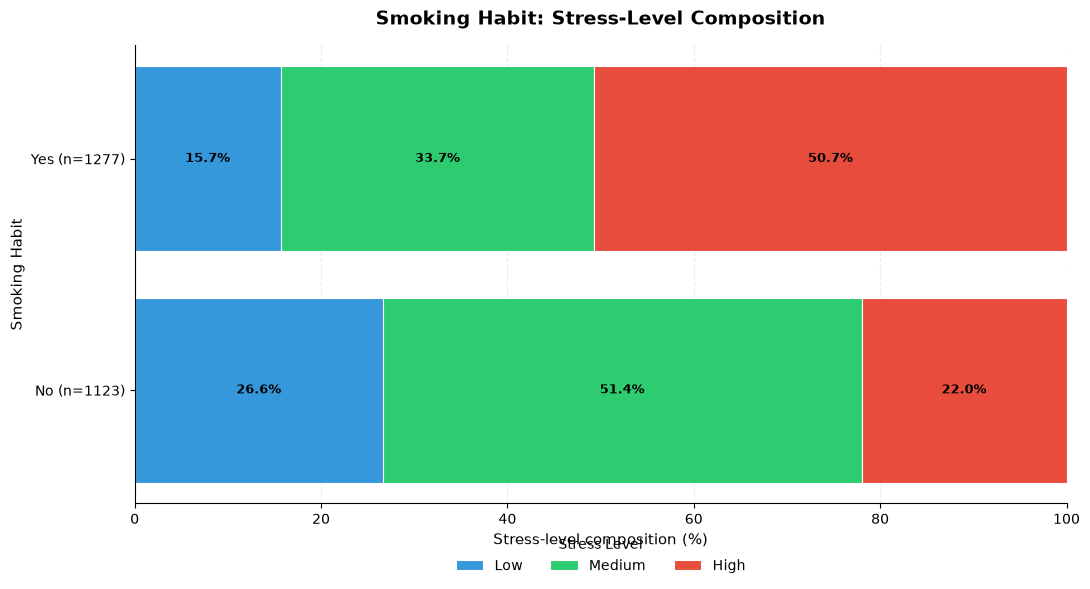

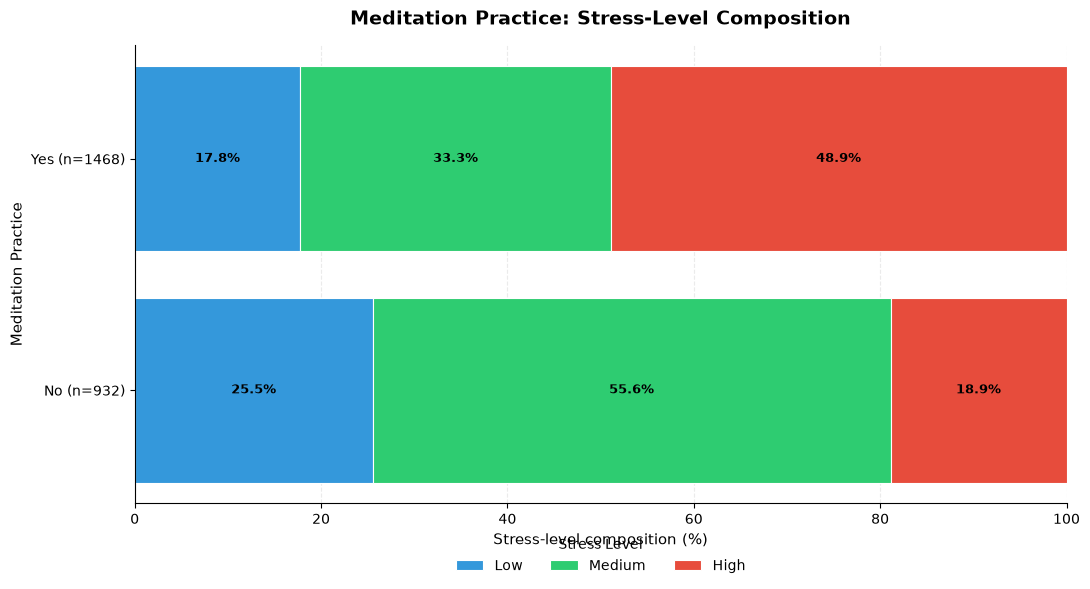

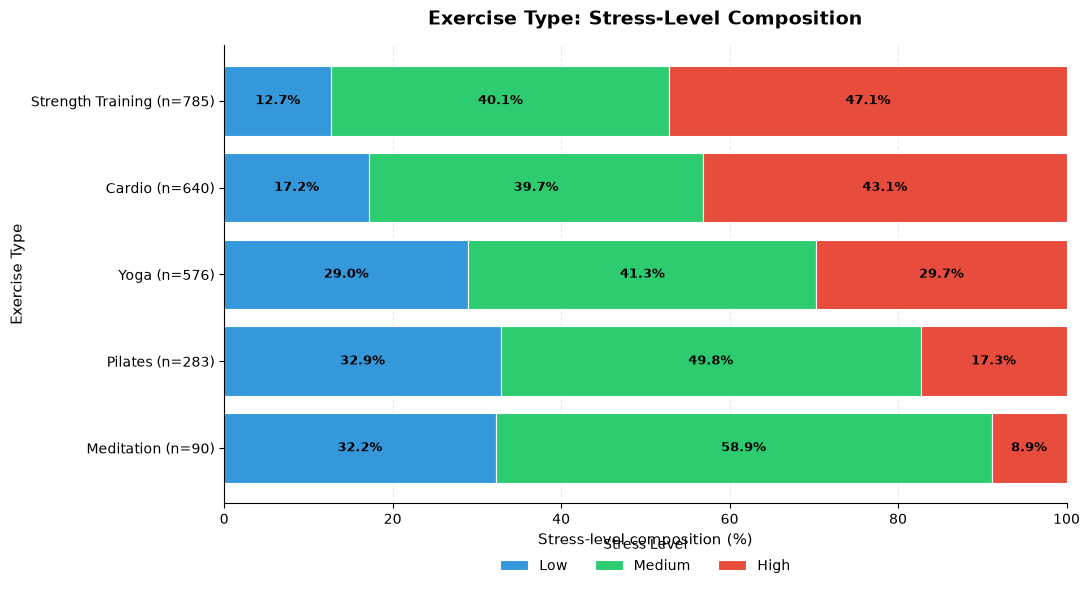

Categorical stress composition analysis completed.


In [ ]:

from matplotlib.patches import Patch

MIN_CATEGORY_N = 25
TOP_CATEGORIES = 10

# Select categorical features
categorical_features = [
    col for col in df.select_dtypes(include=["object", "category"]).columns
    if col != TARGET
]

# Colors for stress levels
STRESS_COLORS = {
    "Low": "#3498DB",
    "Medium": "#2ECC71",
    "High": "#E74C3C"
}

for feature in categorical_features:

    # Keep categories with enough observations
    category_counts = df[feature].value_counts(dropna=False)

    valid_categories = category_counts[
        category_counts >= MIN_CATEGORY_N
    ].index.tolist()

    if len(valid_categories) == 0:
        print(f"Skipped {feature}: no category has at least {MIN_CATEGORY_N} observations.")
        continue

    # If high-cardinality, keep the most frequent categories
    if len(valid_categories) > TOP_CATEGORIES:
        valid_categories = (
            category_counts.loc[valid_categories]
            .sort_values(ascending=False)
            .head(TOP_CATEGORIES)
            .index
            .tolist()
        )

    temp = df[df[feature].isin(valid_categories)].copy()

    # Percentage composition within each category
    composition = pd.crosstab(
        temp[feature],
        temp[TARGET],
        normalize="index"
    ) * 100

    # Ensure all stress levels exist
    composition = composition.reindex(
        columns=STRESS_ORDER,
        fill_value=0
    )

    # Add sample size
    sample_sizes = temp[feature].value_counts()

    # Sort by High-stress proportion
    composition = composition.sort_values(
        by="High",
        ascending=True
    )

    # Create readable labels
    labels = [
        f"{category} (n={sample_sizes.loc[category]})"
        for category in composition.index
    ]

    # Plot
    fig, ax = plt.subplots(
        figsize=(11, max(6, len(composition) * 0.55))
    )

    left = np.zeros(len(composition))

    for stress in STRESS_ORDER:

        values = composition[stress].values

        bars = ax.barh(
            labels,
            values,
            left=left,
            color=STRESS_COLORS[stress],
            edgecolor="white",
            linewidth=0.8,
            label=stress
        )

        # Percentage labels
        for bar, value, start in zip(
            bars,
            values,
            left
        ):
            if value >= 5:
                ax.text(
                    start + value / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold"
                )

        left += values

    # Formatting
    ax.set_xlim(0, 100)

    ax.set_xlabel(
        "Stress-level composition (%)",
        fontsize=11
    )

    ax.set_ylabel(
        feature.replace("_", " "),
        fontsize=11
    )

    ax.set_title(
        f"{feature.replace('_', ' ')}: Stress-Level Composition",
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    ax.legend(
        title="Stress Level",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=3,
        frameon=False
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.25
    )

    ax.set_axisbelow(True)

    # Clean appearance
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    # Save
    safe_name = feature.lower().replace(" ", "_")

    output_path = (
        RESULTS_DIR /
        f"13_categorical_stress_composition_{safe_name}.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # Save numerical data
    composition_output = composition.copy()

    composition_output["Total_N"] = [
        sample_sizes.loc[idx]
        for idx in composition.index
    ]

    composition_output.to_csv(
        RESULTS_DIR /
        f"13_categorical_stress_composition_{safe_name}.csv"
    )

print("Categorical stress composition analysis completed.")

## Categorical association

In [28]:
# Categorical association with stress

categorical_results = []

for feature in categorical_features:

    contingency = pd.crosstab(
        df[feature],
        df[TARGET]
    )

    chi2, p_value, dof, expected = (
        chi2_contingency(
            contingency
        )
    )

    n = contingency.values.sum()

    r, k = contingency.shape

    denominator = min(
        r - 1,
        k - 1
    )

    cramers_v = (
        np.sqrt(
            chi2 /
            (n * denominator)
        )
        if denominator > 0
        else np.nan
    )

    categorical_results.append({
        "feature": feature,
        "categories":
            df[feature].nunique(),
        "chi_square": chi2,
        "degrees_of_freedom": dof,
        "p_value": p_value,
        "cramers_v": cramers_v,
        "expected_cells_below_5":
            (expected < 5).sum(),
        "percent_expected_below_5":
            (expected < 5).mean() * 100
    })

categorical_association = (
    pd.DataFrame(
        categorical_results
    )
    .sort_values(
        "cramers_v",
        ascending=False
    )
)

print(
    "Categorical Features Ranked by "
    "Cramér's V"
)

display(
    categorical_association
)

categorical_association.to_csv(
    RESULTS_DIR /
    "14_categorical_stress_association.csv",
    index=False
)

Categorical Features Ranked by Cramér's V


,feature,categories,chi_square,degrees_of_freedom,p_value,cramers_v,expected_cells_below_5,percent_expected_below_5
1,Occupation,165,1368.145100,328,7.057956e-127,0.533882,348,70.303030
6,Meditation_Practice,2,221.849022,2,6.700342e-49,0.304035,0,0.000000
5,Smoking_Habit,2,211.058325,2,1.476614e-46,0.296548,0,0.000000
4,Bed_Time,19,276.914338,36,5.977380e-39,0.240188,12,21.052632
2,Marital_Status,3,204.544250,4,3.960624e-43,0.206430,0,0.000000
7,Exercise_Type,7,191.101395,12,2.228080e-34,0.199531,4,19.047619
3,Wake_Up_Time,10,187.480994,18,3.141936e-30,0.197632,4,13.333333
0,Gender,2,51.160575,2,7.773600e-12,0.146003,0,0.000000


## Stress interaction profile

Features selected for interaction analysis:
['Cholesterol_Level', 'Blood_Pressure', 'Blood_Sugar_Level', 'Caffeine_Intake']


,Cholesterol_Level,Blood_Pressure,Blood_Sugar_Level,Caffeine_Intake
Stress_Detection,,,,
Low,206.258176,128.012325,103.265371,1.298597
Medium,217.201142,136.344628,109.141619,1.644489
High,232.418043,145.328915,119.059049,2.266219


,Cholesterol_Level,Blood_Pressure,Blood_Sugar_Level,Caffeine_Intake
Stress_Detection,,,,
Low,-0.94,-0.99,-0.90,-0.89
Medium,-0.11,-0.03,-0.17,-0.19
High,1.05,1.01,1.07,1.08


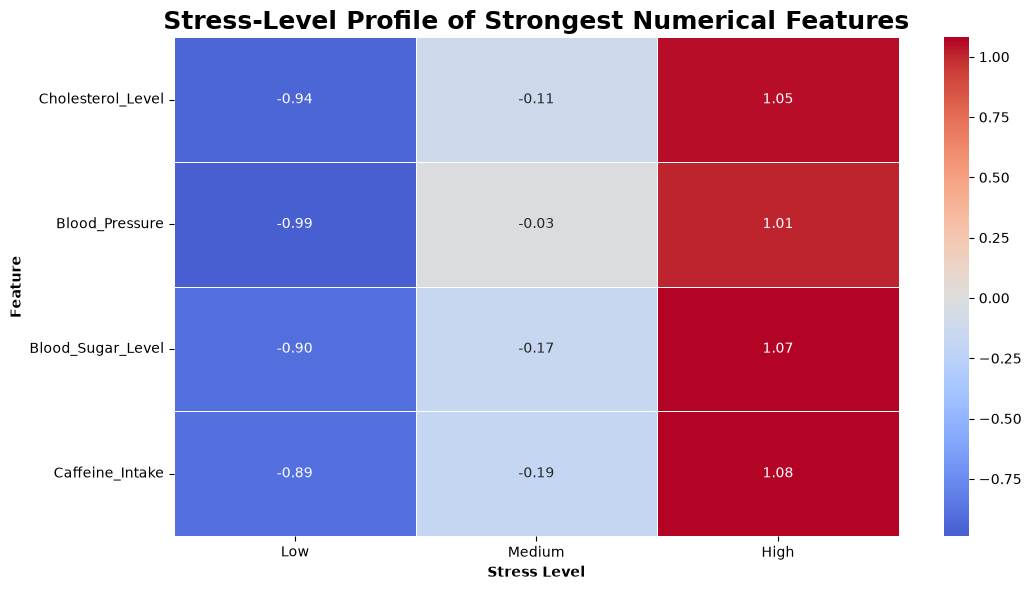


N04 Development EDA completed.
Results saved to: F:\StressGNN\data\processed\eda


In [29]:
# Interaction analysis among strongest numerical features

interaction_features = (
    numerical_association
    .head(
        min(
            4,
            len(numerical_association)
        )
    )
    ["feature"]
    .tolist()
)

print(
    "Features selected for interaction analysis:"
)

print(
    interaction_features
)

# Create stress-wise standardized means
interaction_profile = (
    df.groupby(
        TARGET,
        observed=False
    )[interaction_features]
    .mean()
    .reindex(
        STRESS_ORDER
    )
)

# Standardize across stress groups for visualization
interaction_z = (
    interaction_profile -
    interaction_profile.mean()
) / interaction_profile.std()

display(
    interaction_profile
)

display(
    interaction_z.round(2)
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

sns.heatmap(
    interaction_z.T,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm",
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    "Stress-Level Profile of Strongest Numerical Features",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel(
    "Stress Level",
    fontweight="bold"
)

ax.set_ylabel(
    "Feature",
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR /
    "15_stress_feature_interaction_profile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

interaction_profile.to_csv(
    RESULTS_DIR /
    "15_stress_feature_profile.csv"
)

interaction_z.to_csv(
    RESULTS_DIR /
    "15_stress_feature_profile_standardized.csv"
)

print("\nN04 Development EDA completed.")
print(
    f"Results saved to: {RESULTS_DIR}"
)

##  N04: Development EDA - Key Findings

* **Dataset:** 2,400 development samples, 22 variables (13 numerical, 8 categorical); no missing values or duplicate rows. Frozen test set was not used.
* **Data quality:** Negative values were detected in `Travel_Time`, `Physical_Activity`, `Social_Interactions`, and `Screen_Time`; these require explicit treatment during N06 preprocessing.
* **Class distribution:** Low = 20.79%, Medium = 41.96%, High = 37.25%; majority/minority ratio = **2.02:1**, indicating moderate class imbalance.
* **Strongest numerical associations:** `Cholesterol_Level` (ρ=0.507), `Blood_Pressure` (ρ=0.493), `Blood_Sugar_Level` (ρ=0.490), and `Caffeine_Intake` (ρ=0.451).
* **Feature redundancy:** Strong correlations exist among `Cholesterol_Level`, `Blood_Sugar_Level`, and `Blood_Pressure` (ρ=0.846–0.934), indicating substantial shared information.
* **PCA structure:** PC1 explains 37.80% and the first two PCs explain 49.35% of numerical variance, indicating a multidimensional feature space.
* **Categorical structure:** `Occupation` has very high cardinality (165 categories), requiring careful encoding; its contingency table also has substantial sparse cells.
* **Categorical associations:** `Occupation`, `Meditation_Practice`, and `Smoking_Habit` show the largest Cramér's V values, while sparse-cell effects require caution in interpretation.
* **Multivariate pattern:** The strongest numerical features show a consistent standardized gradient from Low → Medium → High stress.
* **Modeling implication:** The dataset contains moderate imbalance, correlated predictors, nonlinear/interaction potential, and high-cardinality categorical variables. These will be addressed through leakage-safe preprocessing and comparative evaluation of classical ML and GNN models.

**Conclusion:** N04 establishes the key data-quality, class-distribution, feature-association, redundancy, categorical, and multivariate patterns needed for the subsequent modeling pipeline. No feature selection or model decision is made solely from EDA.
